# Day 8

We have done more optimization by removing the Neuron class and just having 2 classes Layer and MLP.

Now we will do our last optimization which is just having 1 instance, as right now as well we are referencing Layer objects in MLP, we need to transform it to just have a NN which will be using vectors/matrices with float value for the whole netowrk. No need to call any pyton object.

### Our last optimized state

In [ ]:
class Layer:
    
    def __init__(self, n_neurons, n_inputs, activation='ReLU'):
        self.params = [[random.uniform(-1, 1) for _ in range(n_neurons)] for i in range(n_inputs)] 
        # adding for bias
        self.params.append([0] * n_neurons)
        self.param_grad = [[0] * n_neurons for i in range(n_inputs+1)]
        self.activation = activation
        self.Q = [0] * n_neurons
        self.inputs = n_inputs+1 # no. of neurons in input layer
        self.neurons = n_neurons # no. of neurons
        self.input_values = None

    def forward(self, input_layer):
        # Reset if already has some value
        self.Q = [0] * self.neurons
        # layer output will have output length as no. of neurons i.e. self.neurons
        output = [0] * self.neurons
        # this [1.0] is the bias term
        self.input_values = input_layer + [1.0] 
        # we have 2d array of parameters and 1 d array of inputs
        # parameters -> (n_inputs+1, n_neurons), inputs -> (n_inputs+1)
        for j in range(self.neurons):
            for i in range(self.inputs):
                self.Q[j] += self.params[i][j] * self.input_values[i]
        if self.activation == 'tanh':
            output_value =  [math.tanh(Qi) for Qi in self.Q] 
        elif self.activation == 'ReLU':
            output_value = [max(Qi, 0) for Qi in self.Q]
        else:
            output_value = self.Q
        return output_value

    def backward(self, grad_in):
        dfdq = [1] * self.neurons
        if self.activation == 'ReLU':
            dfdq = [1 if Q_i > 0 else 0 for Q_i in self.Q]
        elif self.activation == 'tanh':
            dfdq = [1 - math.tanh(Q_i)**2 for Q_i in self.Q]
        dLdQ = [grad_i * dfdq_i for grad_i, dfdq_i in zip(grad_in, dfdq)]
        for j in range(self.neurons):
            for i in range(self.inputs):
                self.param_grad[i][j] += dLdQ[j] * self.input_values[i]
        dLdX = [0] * (self.inputs - 1)
        for j in range(self.neurons):
            for i in range(self.inputs-1):
                dLdX[i] += dLdQ[j] * self.params[i][j]
        return dLdX

    # we are getting list of parameters by refrence and here as well we need to pass by refrence
    def parameters(self):
        return self.params

    def grads(self):
        return self.param_grad


class MLP:
    
    def __init__(self, layer_list, activation='ReLU'):
        self.layers = [Layer(layer_list[i], layer_list[i-1], activation) for i in range(1,len(layer_list))]
        
    def forward(self, inputs):
        output = inputs
        for layer in self.layers:
            output = layer.forward(output)
        return output

    def backward(self, loss_grad):
        grad_in = loss_grad
        for layer in reversed(self.layers):
            grad_in = layer.backward(grad_in)

    def parameters(self):
        parameters = []
        for layer in self.layers:
            parameters.append(layer.parameters())
        return parameters

    def grads(self):
        grads = []
        for layer in self.layers:
            grads.append(layer.grads())
        return grads

## We will remove the layer.
### What does a layer stores
### As discussed in the last optimization we will just need to increase a dimenstion to all the things layer was storing

## Role of a Layer
### What it stores
#### 1. parameter matrix 
#### 2. parameter gradient matrix
#### 3. activation function
#### 4. output of summation before using activation function list
#### 5. input list

### What it does
#### 1. forward i.e output 
#### 2. gradient for each parameter
#### 3. gradient for previous layer
#### 4. also return parameter and its gradients list

In [150]:
import random
import math

In [310]:
class MLP:
    
    def __init__(self, layer_list, activation_list=None):
        self.params = [[[random.uniform(-1, 1)/(math.sqrt(layer_list[i-1])) for _ in range(layer_list[i])] for _ in range(layer_list[i-1])]for i in range(1,len(layer_list))]
        # adding for bias
        for i in range(1,len(layer_list)):
            self.params[i-1].append([0]*layer_list[i])
        self.param_grad = [[[0 for _ in range(layer_list[i])] for _ in range(layer_list[i-1]+1)]for i in range(1,len(layer_list))]
        self.activation_list = activation_list
        self.Q = [[0] * layer_list[i] for i in range(1,len(layer_list))]
        self.input_value = None
        self.output_values = None
        self.layer_list = layer_list
        
    def forward(self, inputs):
        self.input_values = inputs
        # Reset if already has some value
        self.Q = [[0] * self.layer_list[i] for i in range(1,len(self.layer_list))]
        # layer output will have output length as no. of neurons i.e. self.neurons
        self.output_values = [[] for _ in range(len(self.layer_list))]
        self.output_values[0] = inputs + [1.0]
        for k in range(len(self.layer_list)-1):
            # we have 2d array of parameters and 1 d array of inputs
            # parameters -> (n_inputs+1, n_neurons), inputs -> (n_inputs+1)
            for j in range(self.layer_list[k+1]):
                for i in range(self.layer_list[k]+1):
                    self.Q[k][j] += self.params[k][i][j] * self.output_values[k][i]
            if self.activation_list[k] == 'tanh':
                self.output_values[k+1] =  [math.tanh(Qi) for Qi in self.Q[k]] 
            elif self.activation_list[k] == 'ReLU':
                self.output_values[k+1] = [max(Qi, 0) for Qi in self.Q[k]]
            else:
                self.output_values[k+1] = self.Q[k]
            self.output_values[k+1] += [1.0]
        return self.output_values[-1][:-1]
        

    def backward(self, loss_grad):
        
        # dfdq = [[1] * layer_list[i] for i in range(1,len(layer_list))]
        grad_in = loss_grad
        for k in range(len(self.layer_list)-1,0,-1):
            dfdq = [1] * self.layer_list[k]
            if self.activation_list[k-1] == 'ReLU':
                dfdq = [1 if Q_i > 0 else 0 for Q_i in self.Q[k-1]]
            elif self.activation_list[k-1] == 'tanh':
                dfdq = [1 - math.tanh(Q_i)**2 for Q_i in self.Q[k-1]]
            dLdQ = [grad_i * dfdq_i for grad_i, dfdq_i in zip(grad_in, dfdq)]
            for j in range(self.layer_list[k]):
                for i in range(self.layer_list[k-1]+1):
                    self.param_grad[k-1][i][j] += dLdQ[j] * self.output_values[k-1][i]
            dLdX = [0] * (self.layer_list[k-1])
            for j in range(self.layer_list[k]):
                for i in range(self.layer_list[k-1]):
                    dLdX[i] += dLdQ[j] * self.params[k-1][i][j]
            grad_in = dLdX

    def parameters(self):
        return self.params

    def grads(self):
        return self.param_grad

In [311]:
class MSE:
    def __init__(self):
        pass

    def loss(self, y_pred, y_true):
        inputs = len(y_pred)
        ans = 0.0
        grads = []
        for y_predi, y_truei in zip(y_pred,y_true):
            ans += (y_predi-y_truei)**2 
            grads.append(2*(y_predi-y_truei))
        ans /= inputs
        for i in range(inputs):
            grads[i]/=inputs
        return (ans, grads)


class SGD:
    def __init__(self, parameters, grads, learning_rate=0.01):
        self.parameters = parameters
        self.grads = grads
        self.learning_rate = learning_rate

    def step(self):
        for layer_parameters, layer_grads in zip(self.parameters, self.grads):
            for neuron_parameters, neuron_grad in zip(layer_parameters, layer_grads):
                for i in range(len(neuron_parameters)):
                    neuron_parameters[i] -= self.learning_rate * neuron_grad[i]
                    
        
    def zero_grad(self):
        for layer_grads in self.grads:
            for neuron_grads in layer_grads:
                 for i in range(len(neuron_grads)):
                    neuron_grads[i] = 0


In [359]:
inputs = [
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
]
targets = [[0.0], [1.0], [1.0], [0.0]]
nn = MLP([2, 4, 1], ['tanh', 'tanh'])
loss_func = MSE()
optimizer = SGD(nn.parameters(), nn.grads(), 0.5)
epochs = 100
# Training
epoch_values = []
loss_values = []

# we changed from SGD to Batch gradient descent, thats why changed learning rate as well
for epoch in range(epochs):
    total_loss = 0
    for input_value, target in zip(inputs, targets):
        output = nn.forward(input_value)
        loss, loss_grad = loss_func.loss(output, target)
        total_loss += loss
        nn.backward([xi/4 for xi in loss_grad])
    optimizer.step()
    optimizer.zero_grad()
    epoch_values.append(epoch)
    loss_values.append(total_loss)
    if epoch%10 == 0:
        print(f"epoch {epoch}, total loss: {total_loss}")
output = nn.forward([1.0, 1.0])
print(output)

epoch 0, total loss: 2.5670264391362214
epoch 10, total loss: 0.9834969925329076
epoch 20, total loss: 0.9613123856548302
epoch 30, total loss: 0.9218454704699098
epoch 40, total loss: 0.852078888563438
epoch 50, total loss: 0.7416654527752018
epoch 60, total loss: 0.5901640109037044
epoch 70, total loss: 0.4106345330265379
epoch 80, total loss: 0.24631310338933943
epoch 90, total loss: 0.13943940615689593
[0.08909090249846927]


In [357]:
output = nn.forward([1.0, 0.0])
print(output)

[0.644195460361876]


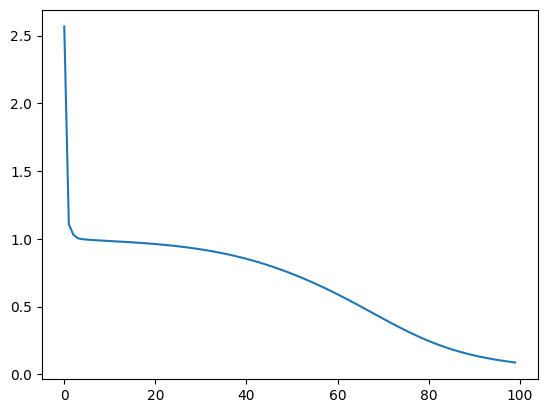

In [360]:
import matplotlib.pyplot as plt
plt.plot(epoch_values,loss_values)